In [139]:
%matplotlib inline
import numpy as np
import jax.numpy as jnp
from jax import value_and_grad
from jax import random
from scipy.optimize import minimize
from dataclasses import dataclass
import matplotlib.pyplot as plt
import seaborn as snb

# we want to use 64 bit floating precision
import jax
jax.config.update("jax_enable_x64", True)

# for plotting
snb.set_style('darkgrid')
snb.set_theme(font_scale=1.25)

# Normal distribution
log_npdf = lambda x, m, v: -0.5*(x-m)**2/(v) - 0.5*jnp.log(2*jnp.pi*v)
npdf = lambda x, m, v: jnp.exp(log_npdf(x, m, v))

# Half-normal distribution
log_half_npdf = lambda x, m, v: jnp.log(2) -0.5*(x-m)**2/(v) - 0.5*jnp.log(2*jnp.pi*v)
half_npdf = lambda x, m, v: jnp.exp(log_half_npdf(x, m, v))

sigmoid = lambda x: 1./(1 + jnp.exp(-x))

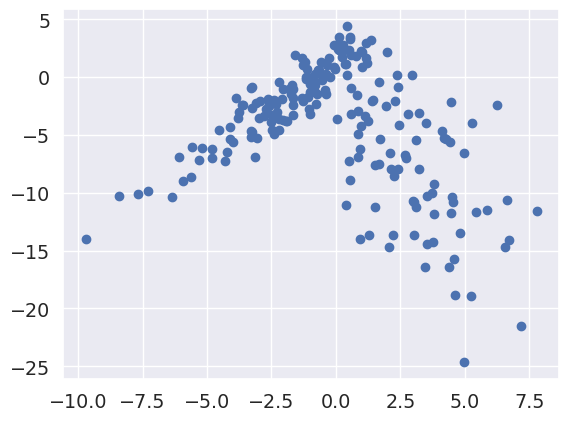

In [140]:
# load data
data = jnp.load('./data_assignment3.npz')
x = data['x']
t = data['t']
N = len(X)
plt.scatter(x, t)

X_train = jnp.hstack((x[:, None], jnp.ones(N)[:, None]))
X_train.shape
y = t

In [141]:
def metropolis(log_target, num_params, tau, num_iter, theta_init=None, seed=0):    
    """ Runs a Metropolis-Hastings sampler 
    
        Arguments:
        log_target:         function for evaluating the log target distribution, i.e. log \tilde{p}(theta). The function expect a parameter of size num_params.
        num_params:         number of parameters of the joint distribution (integer)
        tau:                standard deviation of the Gaussian proposal distribution (positive real)
        num_iter:           number of iterations (integer)
        theta_init:         vector of initial parameters (np.array with shape (num_params) or None)        
        seed:               seed (integer)

        returns
        thetas              np.array with MCMC samples (np.array with shape (num_iter+1, num_params))
    """ 
    
    # set initial key
    key = random.PRNGKey(seed)

    if theta_init is None:
        theta_init = jnp.zeros((num_params))
    
    # prepare lists 
    thetas = [theta_init]
    accepts = []
    log_p_theta = log_target(theta_init)
    
    for k in range(num_iter):

        # update keys: key_proposal for sampling proposal distribution and key_accept for deciding whether to accept or reject.
        key, key_proposal, key_accept = random.split(key, num=3)

        ##############################################
        # Your solution goes here
        ##############################################
        

        # get the last value for theta and generate new proposal candidate
        theta_cur = thetas[-1]
        theta_star = theta_cur + tau*random.normal(key_proposal, shape=(num_params, ))
        
        # evaluate the log density for the candidate sample
        log_p_theta_star = log_target(theta_star)

        # compute acceptance probability
        log_r = log_p_theta_star - log_p_theta
        A = min(1, jnp.exp(log_r))
        
        # accept new candidate with probability A
        if random.uniform(key_accept) < A:
            theta_next = theta_star
            log_p_theta = log_p_theta_star
            accepts.append(1)
        else:
            theta_next = theta_cur
            accepts.append(0)


        
        ##############################################
        # End of solution
        ##############################################
            
        thetas.append(theta_next)


        
    print('Acceptance ratio: %3.2f' % jnp.mean(jnp.array(accepts)))
    print('Final log probability: %3.2f' % log_p_theta.sum())
        
    # return as np.array
    thetas = jnp.stack(thetas)

    # check dimensions and return
    assert thetas.shape == (num_iter+1, num_params), f'The shape of thetas was expected to be ({num_iter+1}, {num_params}), but the actual shape was {thetas.shape}. Please check your code.'
    return thetas


# sanity check: estimate the mean and variance of a N(x|1,3) Gaussian distribution
p_target = lambda x: log_npdf(x, 1., 3.)

# run sampler
thetas = metropolis(p_target, 1, 2., 20000, theta_init=jnp.array([0]))

# estimate the mean and variance of p_target and relative errors
mean_thetas, var_thetas = jnp.mean(thetas), jnp.var(thetas)
rel_err_mean, rel_err_var = (mean_thetas - 1.)/1., (var_thetas - 3.)/3.

print('\nSanity check: Running the sampling with N(x|1, 3) as target')
print(f'Estimated mean:\t\t{mean_thetas:3.2f} (rel. err: {rel_err_mean:3.2f})')
print(f'Estimated variance:\t{var_thetas:3.2f} (rel. err: {rel_err_var:3.2f})\n')

if np.abs(rel_err_mean) < 0.05 and np.abs(rel_err_var) < 0.05:
    print('The relative errors for the first two central moments are less than 5%. Everything looks ok.')
else:
    print('The relative errors for the first two central moments are larger than 5%. If this happens consistently, something is likely wrong. Check your implementation')

Acceptance ratio: 0.67
Final log probability: -1.51

Sanity check: Running the sampling with N(x|1, 3) as target
Estimated mean:		1.05 (rel. err: 0.05)
Estimated variance:	3.09 (rel. err: 0.03)

The relative errors for the first two central moments are larger than 5%. If this happens consistently, something is likely wrong. Check your implementation


In [ ]:
num_params = 9

def log_joint(theta):
    assert(len(theta) == num_params)

    tau = theta[0]   # All these parameters denote the variance even though the assignment is inconsistent
    sigma0 = theta[1]
    sigma1 = theta[2]

    w0 = theta[3:5]
    w1 = theta[5:7]
    v = theta[7:9]

    
    if jnp.any(theta[:3] < 0):
        # print("Negative varaiances. Reject sample")
        return -jnp.inf

    # log hyperprior 
    log_hyperprior = jnp.sum(log_half_npdf(theta[:3], 0, 1), axis = -1)

    # log prior 
    log_prior = jnp.sum(log_npdf(theta[3:], 0, tau))
    
    # log likelihood p(y|w)
    sig = sigmoid(X_train@v) # (N,)
    f0 = X_train@w0
    f1 = X_train@w1
    
    models = jnp.hstack(((log_npdf(y, f0, sigma0) + jnp.log(1 - sig))[:, None], (log_npdf(y, f1, sigma1) + jnp.log(sig))[:, None]))

    log_likelihood = jax.scipy.special.logsumexp(models, axis=-1).sum() 
    
    return log_likelihood + log_prior + log_hyperprior

log_joint(jnp.ones(num_params))


Array(-7948.15415699, dtype=float64)

Acceptance ratio: 0.29
Final log probability: -556.37
Mean and variance of samples for theta1: 2.26, 0.29
Mean and variance of samples for theta2: 1.87, 0.07
Mean and variance of samples for theta3: 8.31, 0.21
Mean and variance of samples for theta4: 1.47, 0.00
Mean and variance of samples for theta5: 0.99, 0.03
Mean and variance of samples for theta6: -1.54, 0.03
Mean and variance of samples for theta7: -3.36, 0.37
Mean and variance of samples for theta8: 2.21, 0.19
Mean and variance of samples for theta9: -1.76, 0.19
(5001, 9)
[ 2.25770171  1.86515781  8.31271722  1.46763424  0.98740643 -1.542761
 -3.36029068  2.21151148 -1.75697555]
[0.28563582 0.06982672 0.20620121 0.00346917 0.02771586 0.02950985
 0.36541838 0.18639054 0.19218729]


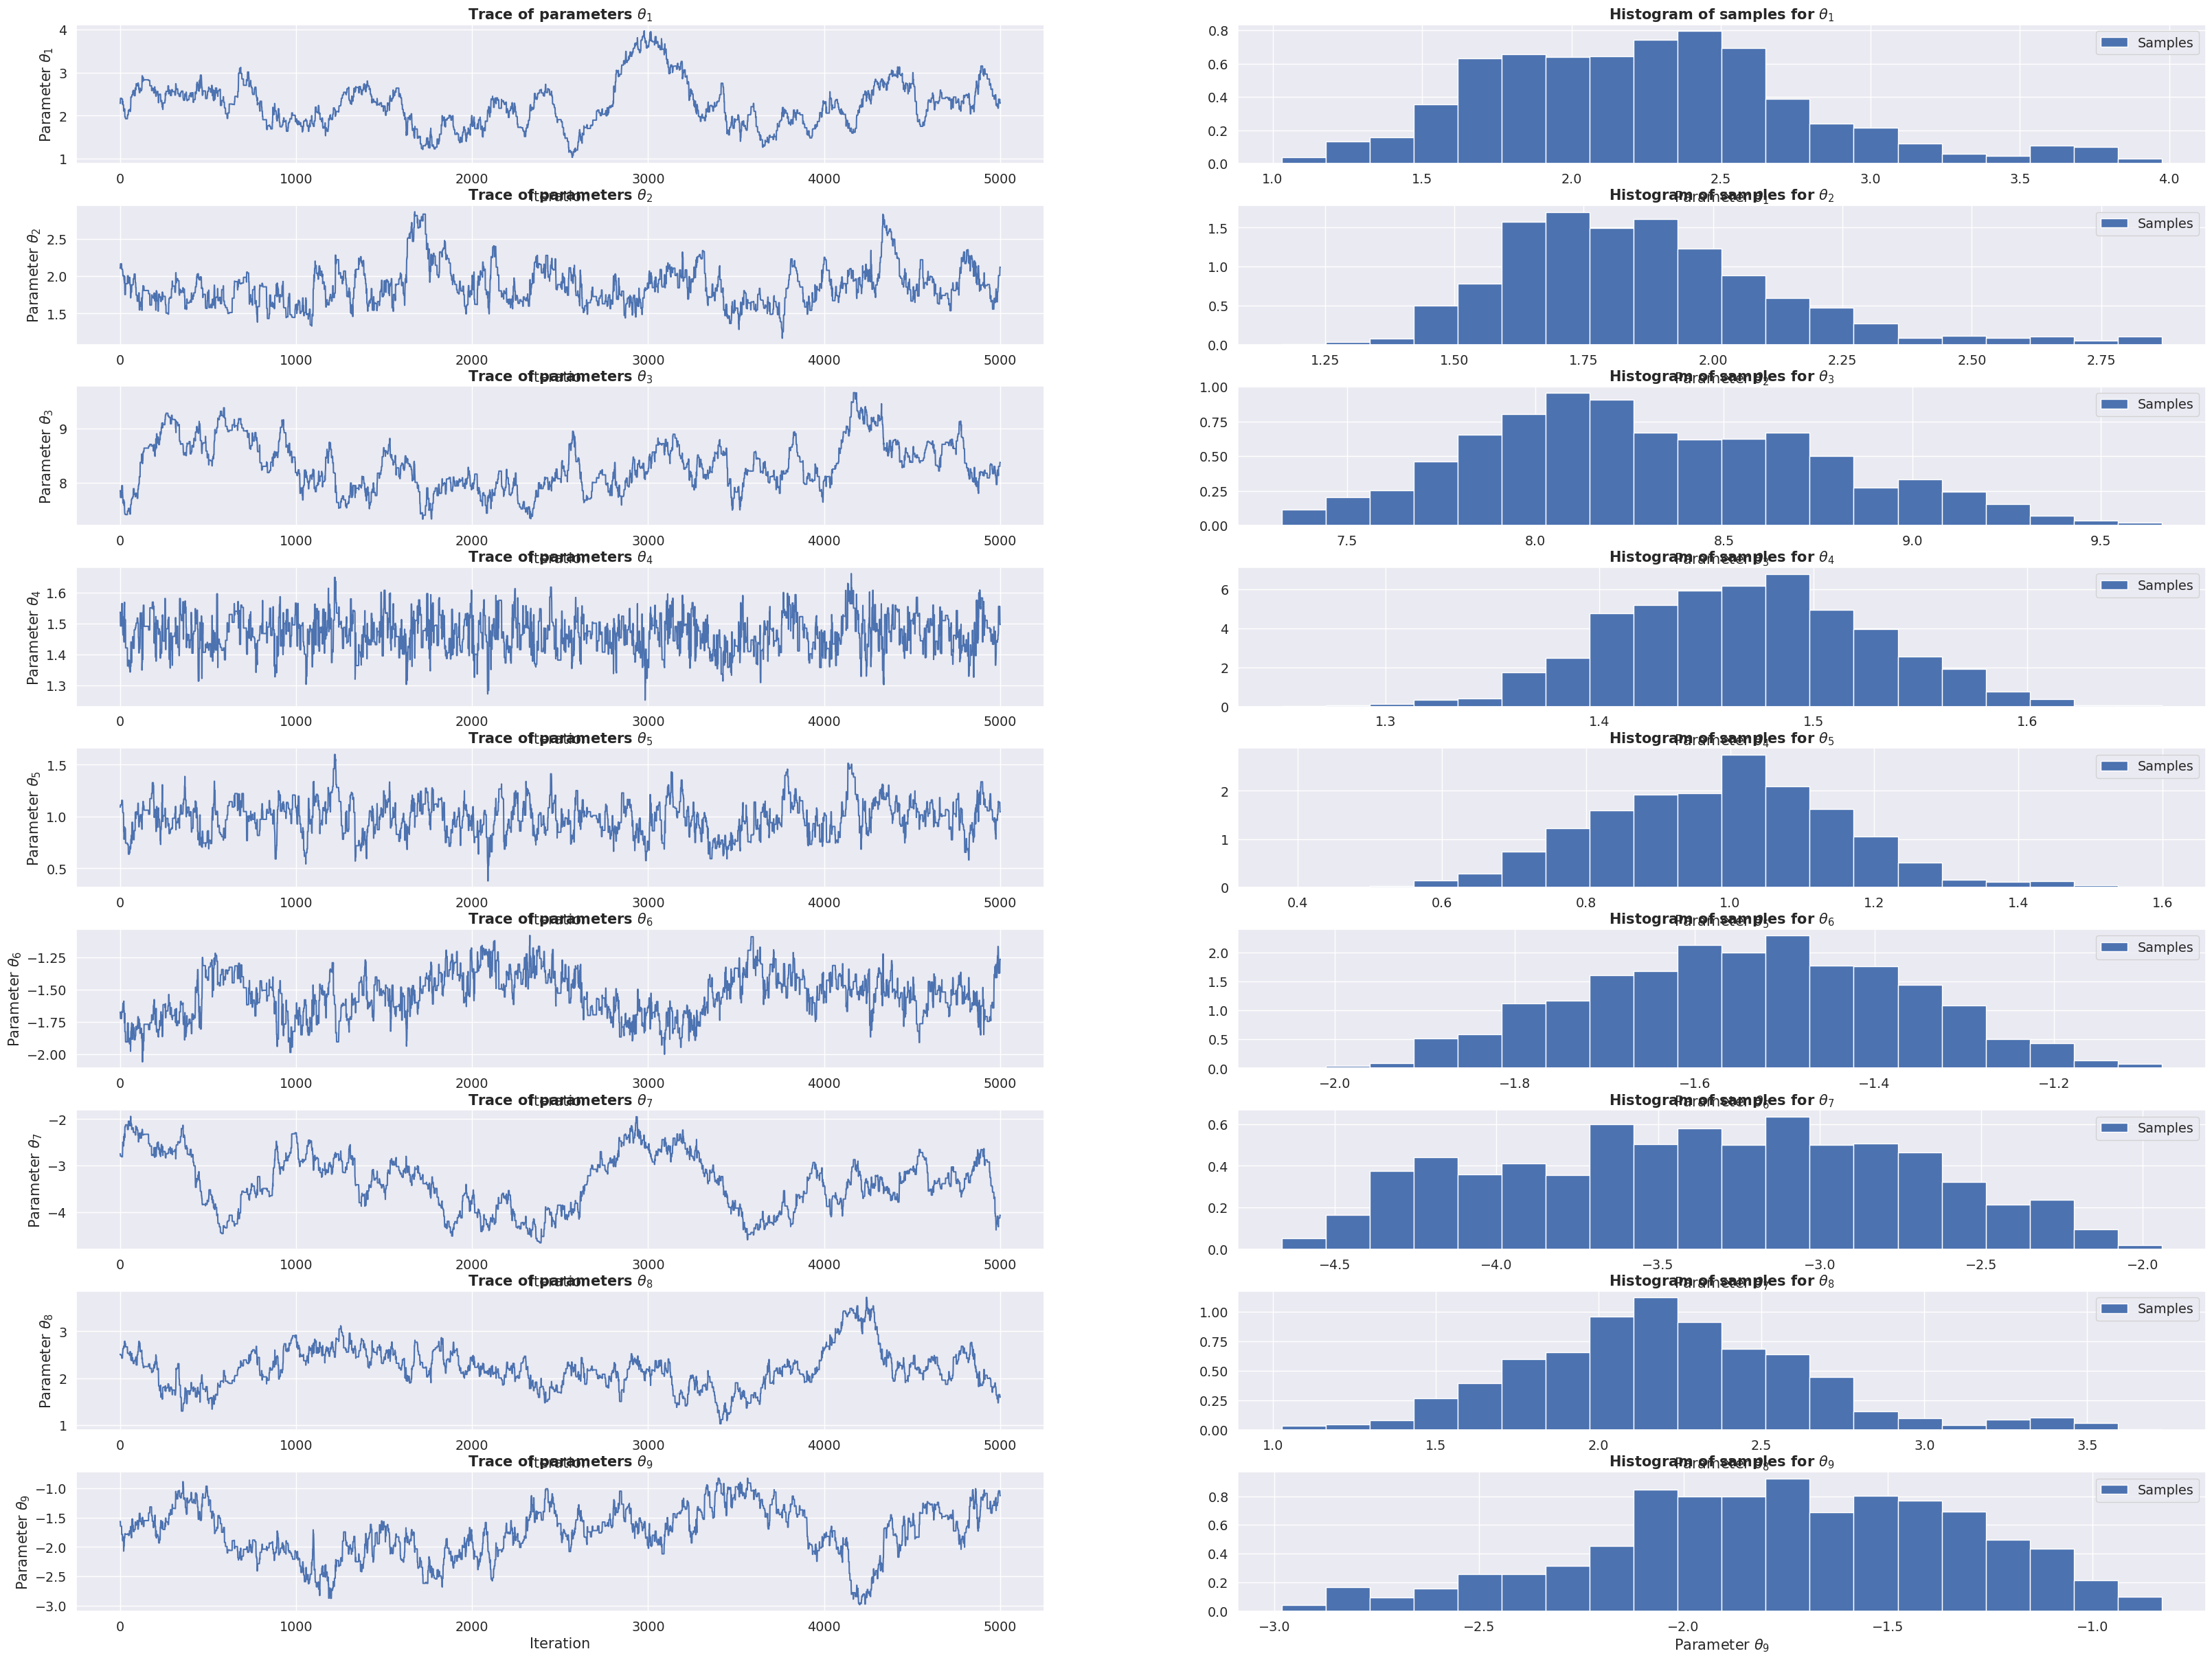

In [143]:
# sampler settings
num_iterations = 10000
warm_up = int(0.5*num_iterations)
tau_mcmc = 0.1

# run sampler
theta_init = jnp.array([1,1,1,1,1,-1,-1,1,-1])
thetas = metropolis(log_joint, num_params, tau_mcmc, num_iterations, seed=0, theta_init=theta_init)

# discard samples from warm-up phase
thetas = thetas[warm_up:, :]

# plot
xs = jnp.linspace(-7.5, 7.5, 100)
fig, axes = plt.subplots(num_params, 2, figsize=(40, 30))
for i in range(num_params):
    axes[i, 0].plot(thetas[:, i])
    axes[i, 0].set_title('Trace of parameters $\\theta_{%d}$' % (i+1), fontweight='bold')
    axes[i, 0].set_xlabel('Iteration')
    axes[i, 0].set_ylabel('Parameter $\\theta_{%d}$' % (i+1))

    axes[i, 1].hist(thetas[:, i], 20, density=True, label='Samples')
    axes[i, 1].set_xlabel('Parameter $\\theta_{%d}$' % (i+1))
    #axes[i, 1].plot(xs, npdf(xs, mu[i], S[i,i]), linewidth=3, label='Exact')
    axes[i, 1].set_title('Histogram of samples for $\\theta_{%d}$' % (i+1), fontweight='bold')
    axes[i, 1].legend()
    
    print('Mean and variance of samples for theta%d: %3.2f, %3.2f' % (i+1, jnp.mean(thetas[:, i]), jnp.var(thetas[:, i])) )
    
fig.subplots_adjust(hspace=0.3)
print(thetas.shape)
print(jnp.mean(thetas, axis = 0))
print(jnp.var(thetas, axis = 0))

In [144]:
theta = thetas.mean(axis = 0)
w0 = theta[3:5]
w1 = theta[5:7]
v = theta[7:9]

# log likelihood p(y|w)
sig = sigmoid(X_train@v) # (N,)
f0 = X_train@w0
f1 = X_train@w1

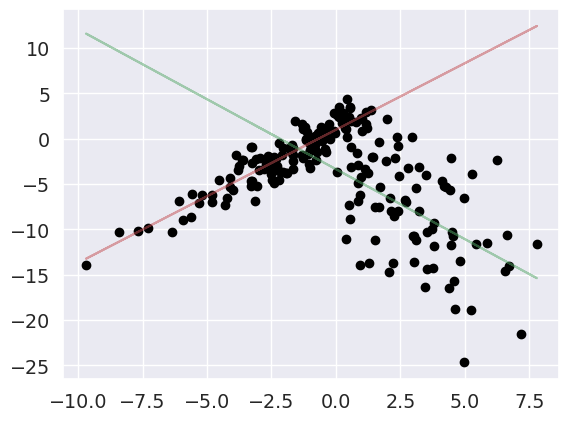

In [145]:

plt.scatter(x, y, color = "black")
plt.plot(x, f0, "r", alpha = 0.5)
plt.plot(x, f1, "g", alpha = 0.5)
# plt.scatter(x, sig*20 - 10, color = "r", alpha = 0.5)

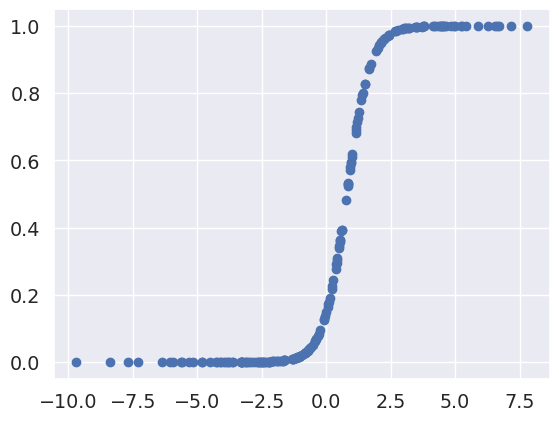

In [146]:
plt.scatter(x, sig)

In [147]:
N, _ = thetas.shape
mean = jnp.mean(thetas, axis=0)

low = jnp.sort(thetas, axis = 0)[int(N*0.025)]
high = jnp.sort(thetas, axis = 0)[int(N*0.975)]

print(mean)
print(low)
print(high)

[ 2.25770171  1.86515781  8.31271722  1.46763424  0.98740643 -1.542761
 -3.36029068  2.21151148 -1.75697555]
[ 1.32995155  1.47062892  7.52033284  1.35793014  0.67594608 -1.87166565
 -4.43229737  1.44688788 -2.72365706]
[ 3.58752745  2.5764132   9.23031647  1.58100967  1.30774177 -1.20869036
 -2.28435736  3.29911589 -1.01153208]


In [165]:
# plot data
def plot_data(ax):
    ax.scatter(x, y, color = "black")

def plot_summary(ax, x, s, interval=95, num_samples=100, sample_color='k', sample_alpha=0.4, interval_alpha=0.25, color='r', legend=True, title="", plot_mean=True, plot_median=False, label="", seed=0):
    
    b = 0.5*(100 - interval)
    
    lower = np.percentile(s, b, axis=0).T
    upper = np.percentile(s, 100-b, axis=0).T
    
    if plot_median:
        median = np.percentile(s, [50], axis=0).T
        lab = 'Median'
        if len(label) > 0:
            lab += " %s" % label
        ax.plot(x.ravel(), median, label=lab, color=color, linewidth=4)
        
    if plot_mean:
        mean = np.mean(s, axis=0).T
        lab = 'Mean'
        if len(label) > 0:
            lab += " %s" % label
        ax.plot(x.ravel(), mean, '--', label=lab, color=color, linewidth=4)
    ax.fill_between(x.ravel(), lower.ravel(), upper.ravel(), color=color, alpha=interval_alpha, label='%d%% Interval' % interval)    
    
    if num_samples > 0:
        np.random.seed(seed)
        idx_samples = np.random.choice(range(len(s)), size=num_samples, replace=False)
        ax.plot(x, s[idx_samples, :].T, color=sample_color, alpha=sample_alpha);
    
    if legend:
        ax.legend(loc='best')
        
    if len(title) > 0:
        ax.title(title, fontweight='bold')
        
def plot_predictions(ax, x, s, num_samples=100, sample_color='k', sample_alpha=0.4, color='r', legend=False, plot_median=False, plot_mean=True, seed=123, title=''):

    plot_summary(ax, x, s, color=color, interval=99, num_samples=0, interval_alpha=0.25, plot_mean=False, plot_median=False, legend=legend, seed=seed)
    plot_summary(ax, x, s, color=color, interval=95, num_samples=0, sample_alpha=0.1, interval_alpha=0.35, plot_mean=False, plot_median=False, legend=legend, seed=seed)
    plot_summary(ax, x, s, color=color, interval=75, interval_alpha=0.6, num_samples=num_samples, sample_alpha=sample_alpha, plot_mean=False, plot_median=False, legend=legend, seed=seed, sample_color=sample_color)
    
    if plot_median:
        median = np.percentile(s, [50], axis=0).T
        ax.plot(x.ravel(), median, label='Median', color='k', linewidth=4, alpha=0.7)
        
    if plot_mean:
        mean = np.mean(s, axis=0).T
        ax.plot(x.ravel(), mean, '-', label='Mean', color='k', linewidth=4, alpha=0.7)
        
    if title:
        ax.set_title(title, fontweight='bold')

    if legend:
        ax.legend(loc='best')




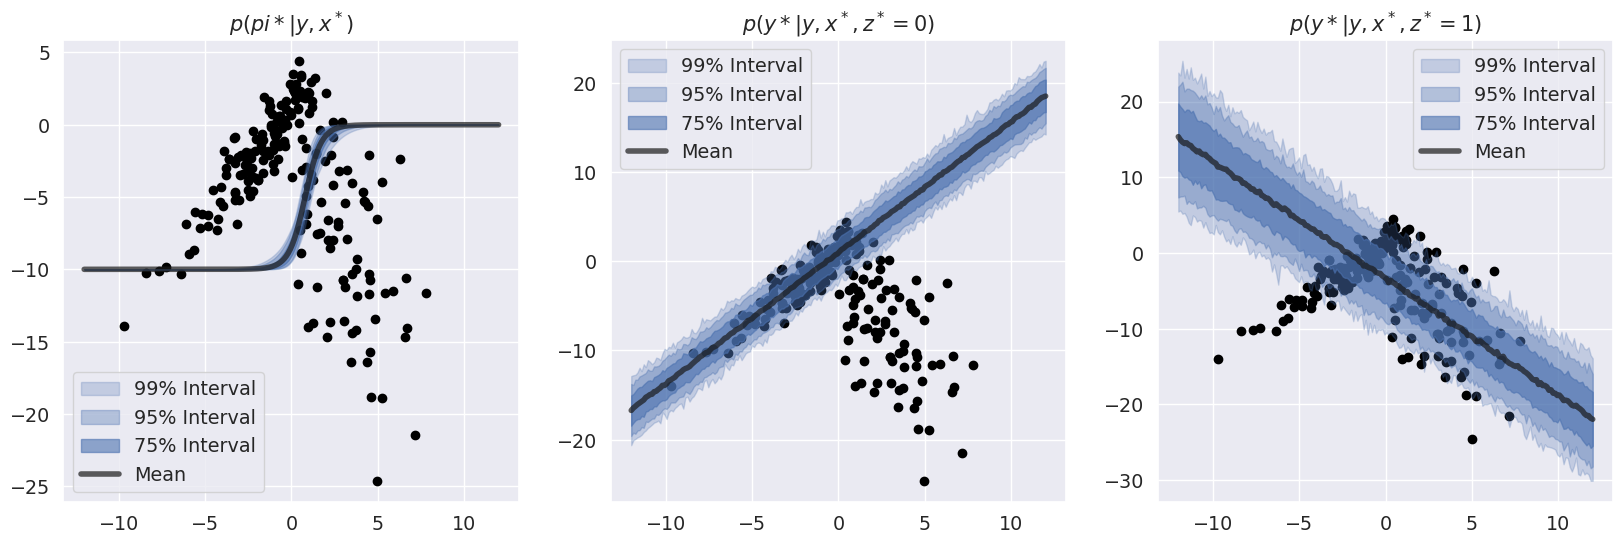

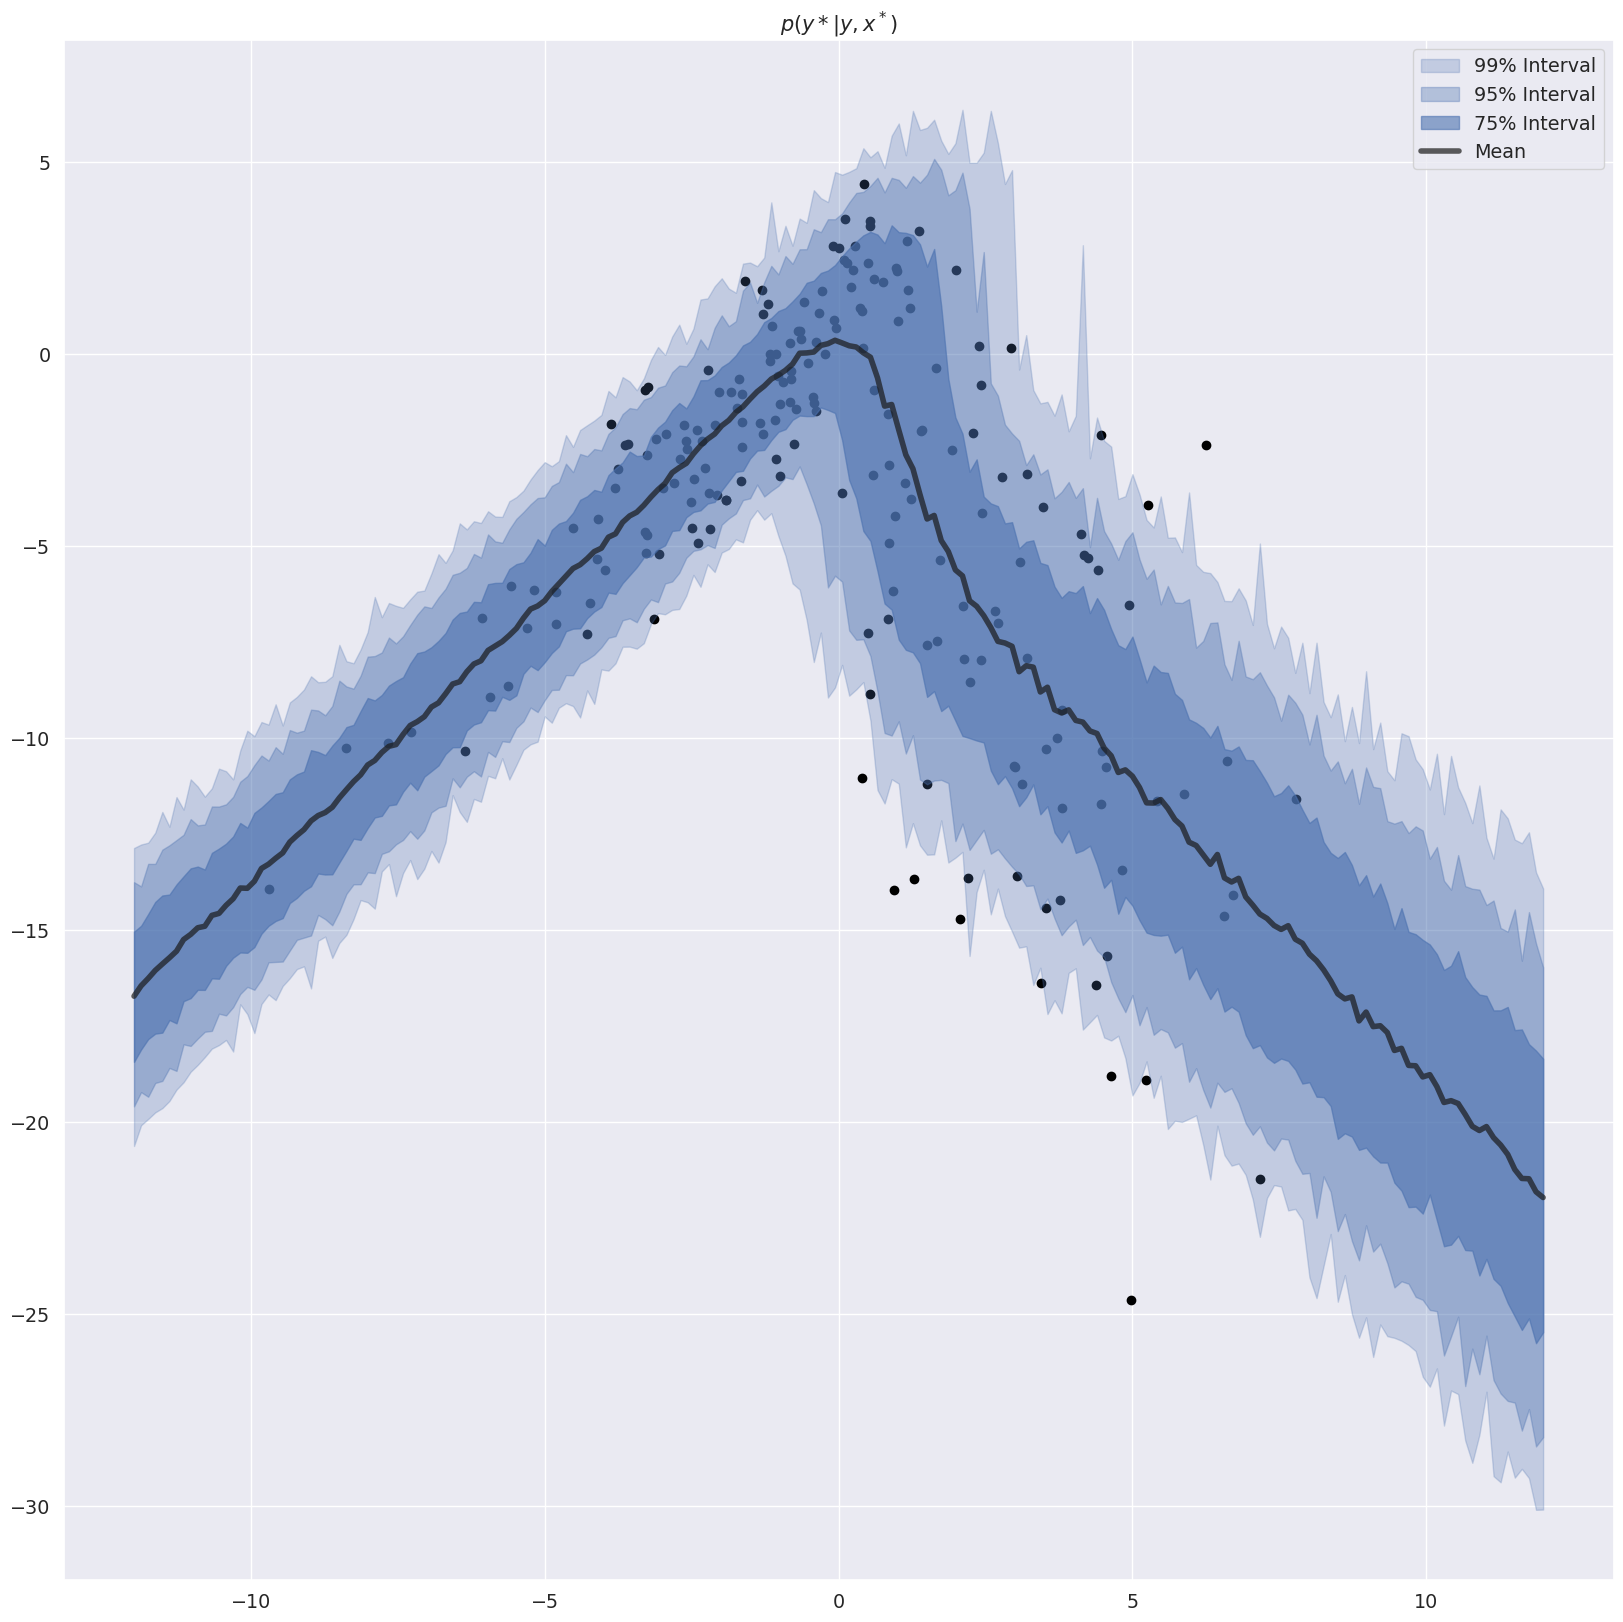

In [170]:
# warm_up = int(0.5*num_iterations) # use 50% for warm-up
thin = 10                         # skip every 10th samples to speed up computations and decorrelate samples

fig, ax = plt.subplots(1, 3, figsize=(20, 6))

ax[0].set(title='$p(pi*|y, x^*)$')
ax[1].set(title='$p(y*|y, x^*,z^* = 0)$')
ax[2].set(title='$p(y*|y, x^*,z^* = 1)$')

x_pred = jnp.linspace(-12, 12, 200)
x_star = jnp.hstack((x_pred[:, None], jnp.ones(len(x_pred))[:, None]))
pi_samples, y0_samples, y1_samples, y_samples  = [], [], [], []
key = random.PRNGKey(1)
for theta_i in thetas[::thin]: # These are all sampled from the posterior distribution (correlated MCMC samples). 
    key, n1_key, n2_key, b_key = random.split(key, num = 4)

    tau = theta_i[0] # All are varainces
    sigma0 = theta_i[1]
    sigma1 = theta_i[2]

    # Set parameters
    w0 = theta_i[3:5]
    w1 = theta_i[5:7]
    v = theta_i[7:9]

    # log likelihood p(y|w)
    pi = sigmoid(x_star@v) # (N,) N = len(x_star)
    pi_samples.append(pi)

    # The two models without noise
    f0 = x_star@w0
    f1 = x_star@w1

    y0 = f0 + jnp.sqrt(sigma0)*random.normal(n1_key, shape=f0.shape)
    y1 = f1 + jnp.sqrt(sigma1)*random.normal(n2_key, shape=f1.shape)
    y0_samples.append(y0)
    y1_samples.append(y1)

    z = random.bernoulli(b_key, pi)
    y_samples.append(z * y1 + (1-z)*y0)

# convert to jax array
pi_samples, y0_samples, y1_samples, y_samples = jnp.stack(pi_samples), jnp.stack(y0_samples), jnp.stack(y1_samples), jnp.stack(y_samples)

plot_data(ax[0])
plot_data(ax[1])
plot_data(ax[2])
# plot using code from week 8
plot_predictions(ax[0], x_pred, pi_samples.squeeze()*10 - 10, num_samples=0, legend=True, sample_alpha=.2, color='b')
plot_predictions(ax[1], x_pred, y0_samples.squeeze(), num_samples=0, legend=True, sample_alpha=.2, color='b')
plot_predictions(ax[2], x_pred, y1_samples.squeeze(), num_samples=0, legend=True, sample_alpha=.2, color='b')
plt.savefig('assignment3_part2.png')
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(20, 20))
ax.set(title='$p(y*|y, x^*)$')
plot_data(ax)
plot_predictions(ax, x_pred, y_samples.squeeze(), num_samples=0, legend=True, sample_alpha=.2, color='b')
plt.savefig('assignment3_part3.png')
plt.show()